# 01 — PreFlight: Data Intake & Quality Control


In [1]:
import sys
from pathlib import Path
REPO = Path.cwd()
for candidate in [REPO, REPO.parent, REPO.parent.parent]:
    if (candidate / "src" / "neuro").exists():
        REPO = candidate
        break
sys.path.insert(0, str(REPO / "src"))
import os
os.chdir(REPO)
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")


In [2]:

import json, psutil
import pandas as pd
import nibabel as nib
import mlflow
from neuro.config import DATA_ROOT, TR_SEC
from neuro.bids import validate_bids, group_counts
from neuro.spark_utils import get_spark, participants_spark
from neuro.mlflow_utils import start_run
from neuro import viz

with start_run("01_pre_flight"):
    report = validate_bids()
    participants = report["participants"]
    runs = report["runs"]
    mlflow.log_param("n_subjects", report["n_subjects"])
    mlflow.log_param("tr_sec", report["tr_json_music"])
    print("=== BIDS Pre-flight ===")
    for k, v in report.items():
        if k not in ("missing", "runs", "participants"):
            print(f"{k}: {v}")
    print("\nGroup counts:")
    display(group_counts())
    print(f"\nMemory available: {psutil.virtual_memory().available / 1e9:.1f} GB")


/home/al/.pyenv/versions/3.10.10/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


=== BIDS Pre-flight ===
n_subjects: 39
n_mdd: 19
n_nd: 20
n_runs_expected: 195
n_runs_available: 195
n_missing_bold: 0
tr_json_music: 3.0
tr_json_nonmusic: 3.0
tr_expected: 3.0

Group counts:


,group_short,n,age_mean,age_std
0,MDD,19,33.526316,13.716853
1,ND,20,29.450000,11.255291



Memory available: 44.9 GB


In [3]:

spark = get_spark("BladerunnerNeuro_PreFlight")
spark.sql("SELECT 'Spark ready for scaled preprocessing' AS status").show()
participants_spark(spark, participants).groupBy("group_short").count().show()


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/22 06:57:10 WARN Utils: Your hostname, frbbmaster002, resolves to a loopback address: 127.0.1.1; using 192.168.1.30 instead (on interface enp11s0)
26/06/22 06:57:10 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/22 06:57:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/06/22 06:57:11 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in standalone/kubernetes and LOCAL_DIRS in YARN).


+--------------------+
|              status|
+--------------------+
|Spark ready for s...|
+--------------------+



+-----------+-----+
|group_short|count|
+-----------+-----+
|         ND|   20|
|        MDD|   19|
+-----------+-----+



Sample: /home/al/Documents/oui/interviews/Neuroscience/data/raw/ds000171/sub-control01/func/sub-control01_task-music_run-1_bold.nii.gz
Shape: (80, 80, 50, 105) Zooms: (np.float32(2.9), np.float32(2.9), np.float32(3.0), np.float32(3.0))


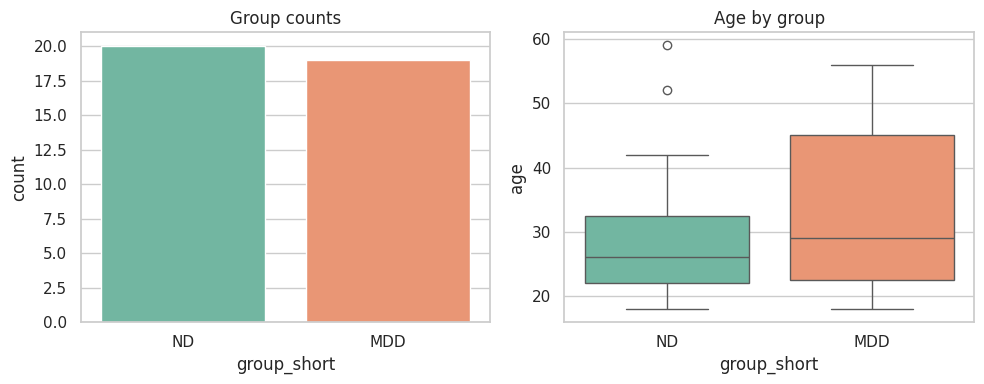

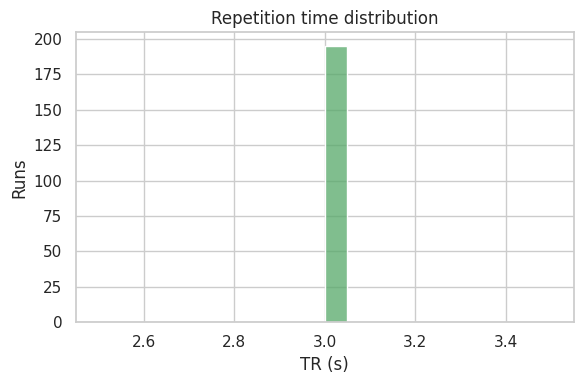

,subject,task,run,bold_path


In [4]:

if report["n_runs_available"]:
    sample = runs[runs["bold_exists"]].iloc[0]
    img = nib.load(sample["bold_path"])
    print("Sample:", sample["bold_path"])
    print("Shape:", img.shape, "Zooms:", img.header.get_zooms())
viz.plot_group_demographics(participants)
plt.show()
viz.plot_tr_histogram(runs)
plt.show()
report["missing"].head(10)
